# YetiRankを用いたcatboost予測

- コードの流れ
1. catboostでYetiRank(損失関数, ランキングモデル)を用いて学習して顧客の商品に対するスコアを計算する
2. catboostで学習したスコアを顧客毎に計算して高い商品を推薦する(※12個未満の場合あり)
3. 2で12個に足りなかった場合は，年齢毎に，かつ，直近1週間で人気の商品を推薦する

- YetiRank → 商品間の相対的な順位関係を学習する
- 入力: 正例(購入データ)・負例(未購入データ)
- 出力: 顧客が商品に対して持つ「好ましさのスコア」, 上位に正例が来るように精度を高める
- 12個未満の推薦になる時があるため補完が必要
- NDCGやPFoundなどの評価指標に基づく(NDCG: 理想的な順位に対する実際の順位の近さ，PFound: 満足して検索をやめる確率, 検索して上に良い記事があればそれ以上検索するのをやめるモデルから)
- YetiRank→高速で，おおよその順位の最適化を行う
- YetiRankPairwise→YetiRankよりも高精度だが，計算が重い
- YetiRankにより算出されたスコアは，絶対値の数値ではなく大きさの関係性に意味がある


In [1]:
import pandas as pd, numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier
from catboost import CatBoostRanker
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

print("ok")

ok


In [2]:
# -------------------------
# 1. データ読み込み & サンプリング
# -------------------------
transactions = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/transactions_train.csv")
customers = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/customers.csv")
articles = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/articles.csv")

print("transactions shape: ", transactions.shape)
print("customers shape: ", customers.shape)
print("articles shape: ", articles.shape)

articles.head()

transactions shape:  (31788324, 5)
customers shape:  (1371980, 7)
articles shape:  (105542, 25)


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulded, lightly padded cups that shape the bust and pro..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulded, lightly padded cups that shape the bust and pro..."


Groupwise loss function. OneHotMaxSize set to 10
0:	total: 842ms	remaining: 4m 11s
50:	total: 29.8s	remaining: 2m 25s
100:	total: 1m 16s	remaining: 2m 31s
150:	total: 2m 4s	remaining: 2m 2s
200:	total: 2m 51s	remaining: 1m 24s
250:	total: 3m 39s	remaining: 42.9s
299:	total: 4m 26s	remaining: 0us


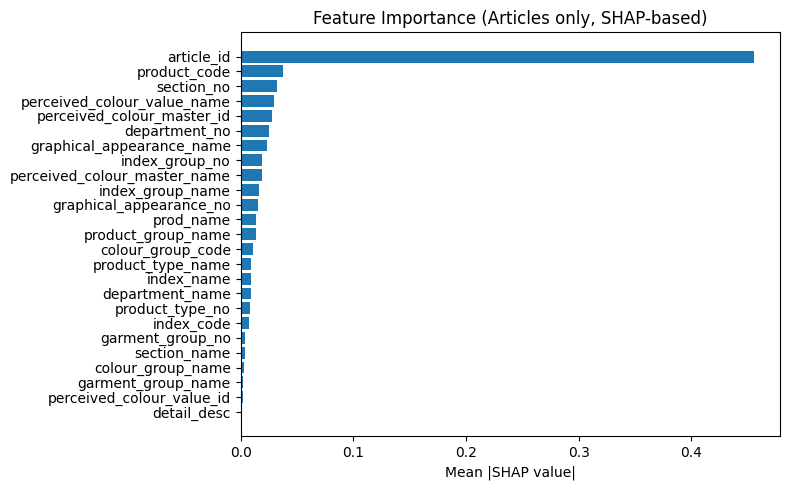

In [3]:
import matplotlib.pyplot as plt
from catboost import CatBoostRanker, Pool  # グラフ描画とCatBoostのランク学習に必要なライブラリ

# -------------------------
# 1.5 正例・負例（1:5）ペア作成
# -------------------------
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])  # 日付型に変換

# 正例：2020-09-15以降に購入された customer_id × article_id のペア
positive = transactions[transactions['t_dat'] >= '2020-09-15'][['customer_id', 'article_id']].drop_duplicates()
positive['target'] = 1  # 正例のターゲットを 1 に設定

# 負例：正例と同じ顧客・商品集合からランダムに5倍サンプリング
np.random.seed(42)
neg = pd.DataFrame({
    'customer_id': np.random.choice(positive['customer_id'].unique(), size=len(positive)*5),
    'article_id': np.random.choice(positive['article_id'].unique(), size=len(positive)*5),
})
neg['target'] = 0  # 負例のターゲットを 0 に設定

# 正例と重複している組み合わせを除外（正例に含まれる customer_id × article_id は除く）
neg = neg[~neg.set_index(['customer_id', 'article_id']).index.isin(
    positive.set_index(['customer_id', 'article_id']).index
)]

# 正例と負例を結合し、学習用のデータフレームを作成
train_df = pd.concat([positive, neg], ignore_index=True)
train_df['group_id'] = train_df['customer_id']  # ランク学習用のグループIDとして customer_id を使う

# -------------------------
# 2. 商品側特徴量だけを使用
# -------------------------
articles_features = articles.copy()  # articles をコピー（マージのため）
train_df_articles_only = train_df[['customer_id', 'article_id', 'target']].copy()  # 必要な列だけ抽出

# 商品特徴量を article_id をキーにして結合
train_df_articles_only = train_df_articles_only.merge(articles_features, on='article_id', how='left')

# 使用する商品特徴量のリストを定義
feature_cols_articles_only = ['article_id', 'product_code', 'prod_name', 'product_type_no',
       'product_type_name', 'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc']

cat_cols_articles_only = feature_cols_articles_only  # カテゴリ列は全て上記の特徴量と同じ（CatBoostに文字列で渡す）

# customer_id順にソート（group_idの順序整備）し、インデックスを振り直す
train_df_articles_only = train_df_articles_only.sort_values('customer_id').reset_index(drop=True)

# カテゴリ列は文字列に変換し、欠損値を "missing" で補完
for col in cat_cols_articles_only:
    train_df_articles_only[col] = train_df_articles_only[col].astype(str).fillna("missing")

# CatBoost用の Pool を作成（特徴量・ターゲット・グループID・カテゴリ列を含める）
train_pool_articles_only = Pool(
    data=train_df_articles_only[feature_cols_articles_only],
    label=train_df_articles_only['target'],
    group_id=train_df_articles_only['customer_id'],
    cat_features=cat_cols_articles_only
)

# -------------------------
# 3. モデル学習（YetiRank）
# -------------------------
model_articles_only = CatBoostRanker(  # ランキングモデルのインスタンス
    iterations=300,                  # 学習ステップ数
    learning_rate=0.1,               # 学習率
    loss_function='YetiRank',        # 損失関数にYetiRankを指定
    eval_metric='NDCG',              # 評価指標にNDCG（ランキング向け）を使用
    verbose=50                       # 50イテレーションごとに進捗出力
)

model_articles_only.fit(train_pool_articles_only)  # モデル学習を実行

# -------------------------
# 4. SHAPベースの特徴量重要度を可視化
# -------------------------
# SHAP値を取得（全行×全特徴量、最初の列はbase valueなので除外）
shap_values = model_articles_only.get_feature_importance(train_pool_articles_only, type='ShapValues')[:, 1:]

# 各特徴量の平均絶対SHAP値を計算（= 重要度）
importances_mean = np.abs(shap_values).mean(axis=0)

# 可視化用のデータフレームに整形
importance_df = pd.DataFrame({
    'feature': feature_cols_articles_only,
    'importance': importances_mean
}).sort_values(by='importance', ascending=False)

# 特徴量重要度をグラフ描画
plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])  # 上位を上にするため[::-1]
plt.xlabel("Mean |SHAP value|")
plt.title("Feature Importance (Articles only, SHAP-based)")
plt.tight_layout()
plt.show()


In [ ]:
from tqdm import tqdm
import pandas as pd
import numpy as np
from catboost import Pool

# sample_submission から全顧客ID取得
sample_submission = pd.read_csv('/Users/kurokawa/Desktop/kaggle/H&M/sample_submission.csv')
test_customers_all = sample_submission['customer_id'].unique()

# 人気上位100商品を取得
popular_articles_100 = transactions['article_id'].value_counts().head(100).index.tolist()

# -------------------------
# 顧客 × 商品のスコア予測（バッチ処理）
# -------------------------
batch_size = 3000
results = []

for i in tqdm(range(0, len(test_customers_all), batch_size)):
    batch_customers = test_customers_all[i:i+batch_size]

    # 顧客 × 商品 の組み合わせを作成
    tmp = pd.DataFrame([(c, a) for c in batch_customers for a in popular_articles_100],
                       columns=['customer_id', 'article_id'])

    # 特徴量結合
    tmp = tmp.merge(articles_features, on='article_id', how='left')
    tmp['article_id'] = tmp['article_id'].astype(str).str.zfill(10)

    for col in cat_cols_articles_only:
        tmp[col] = tmp[col].astype(str).fillna("missing")

    tmp_pool = Pool(
        data=tmp[feature_cols_articles_only],
        cat_features=cat_cols_articles_only
    )

    # スコア予測
    tmp['score'] = model_articles_only.predict(tmp_pool)

    # 上位12個を抽出
    topk = tmp.sort_values(['customer_id', 'score'], ascending=[True, False]) \
              .groupby('customer_id')['article_id'] \
              .apply(lambda x: list(x.head(12))).reset_index()

    results.append(topk)

# 全バッチ統合
recommendations_df = pd.concat(results, ignore_index=True)

# -------------------------
# 年齢層ごとの補完辞書（直近人気記事×年齢層）
# -------------------------
# t_dat型変換
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# 年齢層変換（ageがNaNの顧客を除外しておく）
customers = customers[~customers['age'].isna()].copy()
customers['age_group3'] = pd.cut(customers['age'], bins=[0, 30, 60, 200], labels=['~30', '31-60', '60~'])

# transactions に年齢層をマージ
transactions = transactions.merge(customers[['customer_id', 'age_group3']], on='customer_id', how='left')

# 直近人気商品ランキング（年齢層ごと）
recent = transactions[transactions['t_dat'] >= '2020-09-14']
top_items_by_age = (
    recent.groupby('age_group3')['article_id']
    .value_counts()
    .groupby(level=0)
    .head(50)
    .reset_index()
    .rename(columns={'article_id': 'article_id_raw'})
)
top_items_by_age['article_id'] = top_items_by_age['article_id_raw'].astype(str).str.zfill(10)
age_group_popular_dict = top_items_by_age.groupby('age_group3')['article_id'].apply(list).to_dict()

# 顧客の年齢層を補完用に取得（test_customers に限定）
age_map = customers[['customer_id', 'age_group3']]
recommendations_df = recommendations_df.merge(age_map, on='customer_id', how='left')

# -------------------------
# 補完関数（年齢層に応じて補完）
# -------------------------
def complete_with_agegroup(row):
    article_list = row['article_id']
    age_group = row['age_group3']
    if len(article_list) >= 12:
        return article_list[:12]
    fallback = age_group_popular_dict.get(age_group, popular_articles_100)
    fill_items = [a for a in fallback if a not in article_list]
    return article_list + fill_items[:12 - len(article_list)]

# 補完適用
recommendations_df['prediction'] = recommendations_df.apply(complete_with_agegroup, axis=1)
recommendations_df.drop(columns=['article_id'], inplace=True)
recommendations_df['prediction'] = recommendations_df['prediction'].apply(lambda x: ' '.join(x))

# -------------------------
# 提出ファイル形式に変換
# -------------------------
submission_df = sample_submission[['customer_id']].merge(recommendations_df, on='customer_id', how='left')
fallback_12 = ' '.join([str(a).zfill(10) for a in popular_articles_100[:12]])
submission_df['prediction'] = submission_df['prediction'].fillna(fallback_12)


100%|██████████| 458/458 [09:23<00:00,  1.23s/it]


✅ バッチ処理＋年齢層補完で安全に出力完了！
(1371980, 3)


In [9]:
submission_df.head()

,customer_id,age_group3,prediction
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657,31-60,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,~30,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,~30,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c5feb1ca5dff07c43e,31-60,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe7fc0f26dd8d65a85a,31-60,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...


In [10]:
submission_df = submission_df.drop(columns=['age_group3'], axis=1)
submission_df.head()

,customer_id,prediction
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c5feb1ca5dff07c43e,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe7fc0f26dd8d65a85a,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...


In [11]:
# 保存
submission_df.to_csv("articles_only_2nd.csv", index=False)
print("✅ バッチ処理＋年齢層補完で安全に出力完了！")
print(submission_df.shape)

✅ バッチ処理＋年齢層補完で安全に出力完了！
(1371980, 2)


In [12]:
# 補完するアルゴリズムが異なるのに，精度が全く同じだったため原因特定をする

import pandas as pd

# CSV読み込み
first = pd.read_csv("articles_only_1st.csv")
second = pd.read_csv("articles_only_2nd.csv")

# 顧客IDでマージ
merged = first.merge(second, on="customer_id", suffixes=("_first", "_second"))

# 顧客ごとに、異なる商品セットがあるかどうか判定
def is_different(row):
    set1 = set(row["prediction_first"].split())
    set2 = set(row["prediction_second"].split())
    return set1 != set2  # 異なればTrue

# 異なるレコードを抽出
merged["is_different"] = merged.apply(is_different, axis=1)
diff_df = merged[merged["is_different"]]

# 結果出力
print(f"🧪 顧客ごとに異なる推薦がある件数: {len(diff_df)} / {len(merged)}")

# 最初の数件を確認（必要なら）
print(diff_df.head())

# 必要なら保存
# diff_df.to_csv("diff_customers.csv", index=False)



🧪 顧客ごとに異なる推薦がある件数: 0 / 1371980
Empty DataFrame
Columns: [customer_id, age_group3, prediction_first, prediction_second, is_different]
Index: []


In [13]:
# 推薦リストの長さ（記事数）を確認
first = pd.read_csv("articles_only_1st.csv")

first['n_items'] = first['prediction'].apply(lambda x: len(x.split()))
print(first['n_items'].value_counts().sort_index())


n_items
12    1371980
Name: count, dtype: int64


In [ ]:
# --- 年齢層 × 直近人気商品ランキングの辞書作成 ---
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
customers['age_group3'] = pd.cut(customers['age'], bins=[0, 30, 60, 200], labels=['~30', '31-60', '60~'])
transactions = transactions.merge(customers[['customer_id', 'age_group3']], on='customer_id', how='left')

recent = transactions[transactions['t_dat'] >= '2020-09-14']
top_items_by_age = (
    recent.groupby('age_group3')['article_id']
    .value_counts()
    .groupby(level=0)
    .head(50)
    .reset_index()
    .rename(columns={'article_id': 'article_id_raw'})
)
top_items_by_age['article_id'] = top_items_by_age['article_id_raw'].astype(str).str.zfill(10)
age_group_popular_dict = top_items_by_age.groupby('age_group3')['article_id'].apply(list).to_dict()


# catboostで12個推薦していて補完が行われなかった場合の確認

In [14]:
# -------------------------
# 1. データ読み込み & サンプリング
# -------------------------
transactions = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/transactions_train.csv")
customers = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/customers.csv")
articles = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/articles.csv")

print("transactions shape: ", transactions.shape)
print("customers shape: ", customers.shape)
print("articles shape: ", articles.shape)

articles.head()

transactions shape:  (31788324, 5)
customers shape:  (1371980, 7)
articles shape:  (105542, 25)


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulded, lightly padded cups that shape the bust and pro..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulded, lightly padded cups that shape the bust and pro..."


Groupwise loss function. OneHotMaxSize set to 10
0:	total: 1.82s	remaining: 9m 5s
50:	total: 38.7s	remaining: 3m 8s
100:	total: 1m 29s	remaining: 2m 56s
150:	total: 2m 18s	remaining: 2m 16s
200:	total: 3m 11s	remaining: 1m 34s
250:	total: 4m 5s	remaining: 47.9s
299:	total: 4m 56s	remaining: 0us


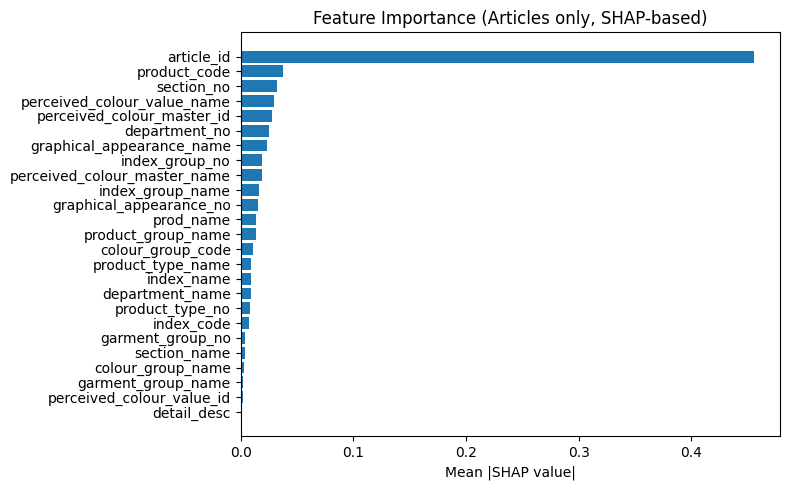

In [15]:
import matplotlib.pyplot as plt
from catboost import CatBoostRanker, Pool  # グラフ描画とCatBoostのランク学習に必要なライブラリ

# -------------------------
# 1.5 正例・負例（1:5）ペア作成
# -------------------------
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])  # 日付型に変換

# 正例：2020-09-15以降に購入された customer_id × article_id のペア
positive = transactions[transactions['t_dat'] >= '2020-09-15'][['customer_id', 'article_id']].drop_duplicates()
positive['target'] = 1  # 正例のターゲットを 1 に設定

# 負例：正例と同じ顧客・商品集合からランダムに5倍サンプリング
np.random.seed(42)
neg = pd.DataFrame({
    'customer_id': np.random.choice(positive['customer_id'].unique(), size=len(positive)*5),
    'article_id': np.random.choice(positive['article_id'].unique(), size=len(positive)*5),
})
neg['target'] = 0  # 負例のターゲットを 0 に設定

# 正例と重複している組み合わせを除外（正例に含まれる customer_id × article_id は除く）
neg = neg[~neg.set_index(['customer_id', 'article_id']).index.isin(
    positive.set_index(['customer_id', 'article_id']).index
)]

# 正例と負例を結合し、学習用のデータフレームを作成
train_df = pd.concat([positive, neg], ignore_index=True)
train_df['group_id'] = train_df['customer_id']  # ランク学習用のグループIDとして customer_id を使う

# -------------------------
# 2. 商品側特徴量だけを使用
# -------------------------
articles_features = articles.copy()  # articles をコピー（マージのため）
train_df_articles_only = train_df[['customer_id', 'article_id', 'target']].copy()  # 必要な列だけ抽出

# 商品特徴量を article_id をキーにして結合
train_df_articles_only = train_df_articles_only.merge(articles_features, on='article_id', how='left')

# 使用する商品特徴量のリストを定義
feature_cols_articles_only = ['article_id', 'product_code', 'prod_name', 'product_type_no',
       'product_type_name', 'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc']

cat_cols_articles_only = feature_cols_articles_only  # カテゴリ列は全て上記の特徴量と同じ（CatBoostに文字列で渡す）

# customer_id順にソート（group_idの順序整備）し、インデックスを振り直す
train_df_articles_only = train_df_articles_only.sort_values('customer_id').reset_index(drop=True)

# カテゴリ列は文字列に変換し、欠損値を "missing" で補完
for col in cat_cols_articles_only:
    train_df_articles_only[col] = train_df_articles_only[col].astype(str).fillna("missing")

# CatBoost用の Pool を作成（特徴量・ターゲット・グループID・カテゴリ列を含める）
train_pool_articles_only = Pool(
    data=train_df_articles_only[feature_cols_articles_only],
    label=train_df_articles_only['target'],
    group_id=train_df_articles_only['customer_id'],
    cat_features=cat_cols_articles_only
)

# -------------------------
# 3. モデル学習（YetiRank）
# -------------------------
model_articles_only = CatBoostRanker(  # ランキングモデルのインスタンス
    iterations=300,                  # 学習ステップ数
    learning_rate=0.1,               # 学習率
    loss_function='YetiRank',        # 損失関数にYetiRankを指定
    eval_metric='NDCG',              # 評価指標にNDCG（ランキング向け）を使用
    verbose=50                       # 50イテレーションごとに進捗出力
)

model_articles_only.fit(train_pool_articles_only)  # モデル学習を実行

# -------------------------
# 4. SHAPベースの特徴量重要度を可視化
# -------------------------
# SHAP値を取得（全行×全特徴量、最初の列はbase valueなので除外）
shap_values = model_articles_only.get_feature_importance(train_pool_articles_only, type='ShapValues')[:, 1:]

# 各特徴量の平均絶対SHAP値を計算（= 重要度）
importances_mean = np.abs(shap_values).mean(axis=0)

# 可視化用のデータフレームに整形
importance_df = pd.DataFrame({
    'feature': feature_cols_articles_only,
    'importance': importances_mean
}).sort_values(by='importance', ascending=False)

# 特徴量重要度をグラフ描画
plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])  # 上位を上にするため[::-1]
plt.xlabel("Mean |SHAP value|")
plt.title("Feature Importance (Articles only, SHAP-based)")
plt.tight_layout()
plt.show()


In [17]:
from tqdm import tqdm
import pandas as pd
import numpy as np
from catboost import Pool

# sample_submission から全顧客ID取得
sample_submission = pd.read_csv('/Users/kurokawa/Desktop/kaggle/H&M/sample_submission.csv')
test_customers_all = sample_submission['customer_id'].unique()

# 人気上位100商品を取得
popular_articles_100 = transactions['article_id'].value_counts().head(100).index.tolist()

# -------------------------
# 顧客 × 商品のスコア予測（バッチ処理）
# -------------------------
batch_size = 3000
results = []

for i in tqdm(range(0, len(test_customers_all), batch_size)):
    batch_customers = test_customers_all[i:i+batch_size]

    # 顧客 × 商品 の組み合わせを作成
    tmp = pd.DataFrame([(c, a) for c in batch_customers for a in popular_articles_100],
                       columns=['customer_id', 'article_id'])

    # 特徴量結合
    tmp = tmp.merge(articles_features, on='article_id', how='left')
    tmp['article_id'] = tmp['article_id'].astype(str).str.zfill(10)

    for col in cat_cols_articles_only:
        tmp[col] = tmp[col].astype(str).fillna("missing")

    tmp_pool = Pool(
        data=tmp[feature_cols_articles_only],
        cat_features=cat_cols_articles_only
    )

    # スコア予測
    tmp['score'] = model_articles_only.predict(tmp_pool)

    # 上位12個を抽出
    topk = tmp.sort_values(['customer_id', 'score'], ascending=[True, False]) \
              .groupby('customer_id')['article_id'] \
              .apply(lambda x: list(x.head(12))).reset_index()

    results.append(topk)

# 全バッチ統合
recommendations_df = pd.concat(results, ignore_index=True)

"""
# -------------------------
# 年齢層ごとの補完辞書（直近人気記事×年齢層）
# -------------------------
# t_dat型変換
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# 年齢層変換（ageがNaNの顧客を除外しておく）
customers = customers[~customers['age'].isna()].copy()
customers['age_group3'] = pd.cut(customers['age'], bins=[0, 30, 60, 200], labels=['~30', '31-60', '60~'])

# transactions に年齢層をマージ
transactions = transactions.merge(customers[['customer_id', 'age_group3']], on='customer_id', how='left')

# 直近人気商品ランキング（年齢層ごと）
recent = transactions[transactions['t_dat'] >= '2020-09-14']
top_items_by_age = (
    recent.groupby('age_group3')['article_id']
    .value_counts()
    .groupby(level=0)
    .head(50)
    .reset_index()
    .rename(columns={'article_id': 'article_id_raw'})
)
top_items_by_age['article_id'] = top_items_by_age['article_id_raw'].astype(str).str.zfill(10)
age_group_popular_dict = top_items_by_age.groupby('age_group3')['article_id'].apply(list).to_dict()

# 顧客の年齢層を補完用に取得（test_customers に限定）
age_map = customers[['customer_id', 'age_group3']]
recommendations_df = recommendations_df.merge(age_map, on='customer_id', how='left')

"""

# -------------------------
# 補完関数（年齢層に応じて補完）
# -------------------------
def complete_with_agegroup(row):
    article_list = row['article_id']
    age_group = row['age_group3']
    if len(article_list) >= 12:
        return article_list[:12]
    fallback = age_group_popular_dict.get(age_group, popular_articles_100)
    fill_items = [a for a in fallback if a not in article_list]
    return article_list + fill_items[:12 - len(article_list)]

# NaNを除いた顧客に限定
customers = customers[~customers['age'].isna()].copy()
customers['age_group3'] = pd.cut(customers['age'], bins=[0, 30, 60, 200], labels=['~30', '31-60', '60~'])

# 年齢層を transactions にマージ（再度必要なら）
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions = transactions.merge(customers[['customer_id', 'age_group3']], on='customer_id', how='left')

# 年齢層ごとの直近人気商品を取得
recent = transactions[transactions['t_dat'] >= '2020-09-14']
top_items_by_age = (
    recent.groupby('age_group3')['article_id']
    .value_counts()
    .groupby(level=0)
    .head(50)
    .reset_index()
    .rename(columns={'article_id': 'article_id_raw'})
)
top_items_by_age['article_id'] = top_items_by_age['article_id_raw'].astype(str).str.zfill(10)
age_group_popular_dict = top_items_by_age.groupby('age_group3')['article_id'].apply(list).to_dict()

# 顧客の年齢層を recommendations_df に付与
age_map = customers[['customer_id', 'age_group3']]
recommendations_df = recommendations_df.merge(age_map, on='customer_id', how='left')

# 推薦結果に補完適用
recommendations_df['prediction'] = recommendations_df.apply(complete_with_agegroup, axis=1)
recommendations_df.drop(columns=['article_id'], inplace=True)
recommendations_df['prediction'] = recommendations_df['prediction'].apply(lambda x: ' '.join(x))



# -------------------------
# 提出ファイル形式に変換
# -------------------------
submission_df = sample_submission[['customer_id']].merge(recommendations_df, on='customer_id', how='left')
fallback_12 = ' '.join([str(a).zfill(10) for a in popular_articles_100[:12]])
submission_df['prediction'] = submission_df['prediction'].fillna(fallback_12)


100%|██████████| 458/458 [09:37<00:00,  1.26s/it]


In [21]:
print(submission_df.shape)

(1371980, 2)


In [20]:
submission_df = submission_df.drop(columns=["age_group3"], axis=1)
submission_df.head()

,customer_id,prediction
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c5feb1ca5dff07c43e,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe7fc0f26dd8d65a85a,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...


In [22]:
# 保存
submission_df.to_csv("confirm.csv", index=False)
print("確認")
print(submission_df.shape)

確認
(1371980, 2)
